# Confronto: le tre generazioni del LLM Sizing Tool vs benchmark reale

> Generato da `build_confronto_old_new.py` — kernel conda `llmcalc`. Dati in `Data/`.

Il 2026-06-10/11 la logica di calcolo del **llm-sizing-tool** è stata riscritta in
due passi: prima il **modello roofline** (con parametri di letteratura), poi la sua
**calibrazione** sul benchmark reale. Questo notebook confronta le tre generazioni
di predizioni sulla stessa matrice sperimentale, con il **benchmark aiperf**
(160 run vLLM su 8×H100 PCIe e 8×H200 NVLink) come riferimento.

| | 1. Vecchio euristico (`sizing_results_legacy.csv`) | 2. Roofline default (`sizing_results_prefit.csv`) | 3. Roofline calibrato (`sizing_results.csv`) |
|---|---|---|---|
| TFLOPS GPU | datasheet *with sparsity* (H100=1979) | dense (H100 SXM=989, PCIe=756) | come 2. |
| H100 PCIe | non esisteva (spec SXM, NVLink off) | profilo dedicato (756 TFLOPS, 2000 GB/s) | come 2. |
| TTFT | `prompt = C×input`, mult. fisso ×2 | prefill singolo / compute eff. × coda (N+1)/2 | come 2. |
| ITL | `2P/banda`, piatto in C | roofline: max(pesi+KV batch, compute batch) | come 2. |
| Multi-GPU no-NVLink | G=1 + penalità `1.2n²−n` | efficienza di scaling per interconnect | come 2. |
| Parametri | impliciti nel codice | `mfu=0.5, mbu=0.8, η=0.9/0.6` (letteratura) | **fittati (soli densi)**: `mfu=0.413, mbu=0.643, η_nv=0.361, η_pcie=0.372` |
| Griglia TP | 1/4/8 | 1/2/4/8 | 1/2/4/8 |

Commit (repo `llm-sizing-tool`, branch `vr_reviews`): `e34cbb1`, `064725f`,
`f924538`, `fb79f5e` + calibrazione (`backend/calibrate_perf_model.py`).
Fit: minimizzazione dell'errore log-assoluto medio su TTFT+ITL sulle **130 config dense**
(147 appaiate totali; gpt-oss-120b escluso dal fit: con i 5.1B attivi della model card
— arXiv:2508.10925, spec pinnata al posto dei 120.4B/27.09B dell'euristica HF — il
roofline lo sottostima ~5×, fuori dal dominio di validità della formula chiusa).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110

DATA = "Data/"
METRICS = ["ttft_avg_ms", "itl_avg_ms", "request_latency_avg_ms"]
KEYS = ["model", "gpu_arch", "interconnect", "n_gpu", "concurrent_users"]
COL = {"vecchio": "#c23b22", "default": "#1f77b4", "calibrato": "#2ca02c", "reale": "#222222"}

def parse_keys(df):
    """Derive join keys from gpu_type: nel reale 'Nx ...' indica il nodo e il TP
    e' in tensor_parallelism; nel teorico il prefisso Nx coincide col TP."""
    s = df["gpu_type"].astype(str)
    df = df.copy()
    df["gpu_arch"] = np.where(s.str.contains("H100"), "H100", "H200")
    df["interconnect"] = np.where(s.str.contains("PCIe"), "PCIe", "NVLink")
    df["n_gpu"] = df["tensor_parallelism"].astype(int)
    return df

real = parse_keys(pd.read_csv(DATA + "benchmark_results.csv"))
preds = {"vecchio":   parse_keys(pd.read_csv(DATA + "sizing_results_legacy.csv")),
         "default":   parse_keys(pd.read_csv(DATA + "sizing_results_prefit.csv")),
         "calibrato": parse_keys(pd.read_csv(DATA + "sizing_results.csv"))}

# il benchmark copre solo questi due sistemi: filtriamo le predizioni di conseguenza
REAL_HW = {("H100", "PCIe"), ("H200", "NVLink")}
hw_mask = lambda df: df.set_index(["gpu_arch", "interconnect"]).index.isin(REAL_HW)
preds = {k: v[hw_mask(v)].copy() for k, v in preds.items()}

print("righe -> reale:", len(real), "|", {k: len(v) for k, v in preds.items()})
print("modelli:", sorted(real.model.unique()))

righe -> reale: 160 | {'vecchio': 117, 'default': 155, 'calibrato': 155}
modelli: ['DeepSeek-R1-Distill-Qwen-32B', 'Llama-3.1-8B-Instruct', 'Llama-3.3-70B-Instruct', 'Qwen2.5-32B-Instruct', 'Qwen2.5-7B-Instruct', 'gpt-oss-120b']


## 1. Cosa è cambiato tra le versioni (solo predizioni)

Il passaggio 1→2 è un **cambio di modello** (shift diversi per regime: su NVLink il
TTFT raddoppia per i TFLOPS dense, su PCIe TTFT e ITL crollano senza la penalità
quadratica). Il passaggio 2→3 è una **ricalibrazione** (riscala i tempi verso
l'alto: `mfu` 0.5→0.413, `mbu` 0.8→0.643 e soprattutto η da 0.9/0.6 a ~0.36-0.37 per
entrambi gli interconnect; fit sui soli modelli densi).

configurazioni comuni 1∩2: 117 (la griglia vecchia non ha TP=2)


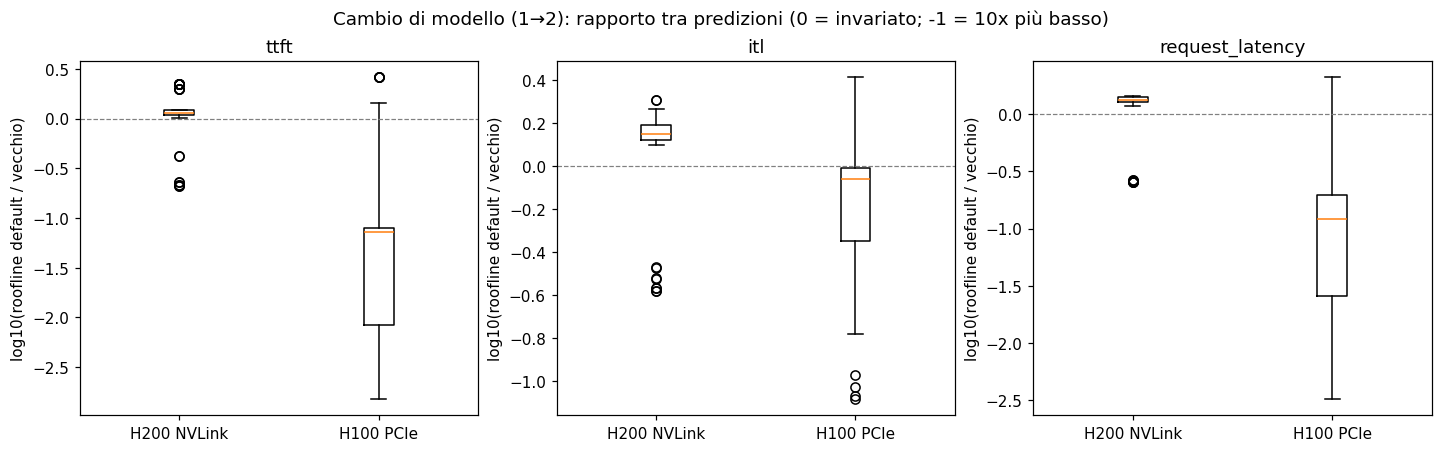

In [2]:
both = preds["vecchio"].merge(preds["default"], on=KEYS, suffixes=("_old", "_new"))
print(f"configurazioni comuni 1∩2: {len(both)} (la griglia vecchia non ha TP=2)")

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, met in zip(axes, METRICS):
    data = [np.log10(both.loc[both.interconnect == ic, met + "_new"] /
                     both.loc[both.interconnect == ic, met + "_old"])
            for ic in ["NVLink", "PCIe"]]
    ax.boxplot(data, tick_labels=["H200 NVLink", "H100 PCIe"])
    ax.axhline(0, color="grey", lw=0.8, ls="--")
    ax.set_title(met.replace("_avg_ms", ""))
    ax.set_ylabel("log10(roofline default / vecchio)")
fig.suptitle("Cambio di modello (1→2): rapporto tra predizioni (0 = invariato; -1 = 10x più basso)")
plt.show()

### L'effetto qualitativo più importante: l'ITL ora dipende dalla concorrenza

Il vecchio modello prediceva un ITL **costante** al variare degli utenti
(leggeva solo i pesi); il benchmark mostra invece una crescita. Il roofline la
cattura tramite la lettura della KV cache di tutto il batch; la calibrazione
riposiziona le curve sui livelli giusti.

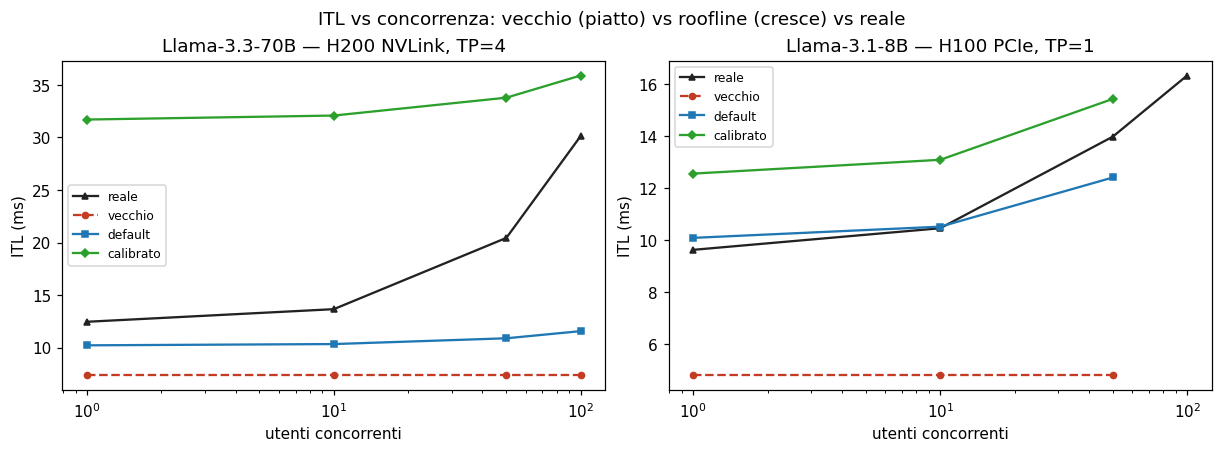

In [3]:
sample = [("Llama-3.3-70B-Instruct", "H200", "NVLink", 4),
          ("Llama-3.1-8B-Instruct", "H100", "PCIe", 1)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, (mod, arch, ic, tp) in zip(axes, sample):
    series = [("reale", real, "-^")] + [(k, v, "--o" if k == "vecchio" else "-s" if k == "default" else "-D")
                                        for k, v in preds.items()]
    for name, df, style in series:
        sub = df[(df.model == mod) & (df.gpu_arch == arch) &
                 (df.interconnect == ic) & (df.n_gpu == tp)].sort_values("concurrent_users")
        if len(sub):
            ax.plot(sub.concurrent_users, sub.itl_avg_ms, style, color=COL[name], label=name, ms=4)
    ax.set_title(f"{mod.split('-Instruct')[0]} — {arch} {ic}, TP={tp}")
    ax.set_xlabel("utenti concorrenti"); ax.set_ylabel("ITL (ms)")
    ax.set_xscale("log"); ax.legend(fontsize=8)
fig.suptitle("ITL vs concorrenza: vecchio (piatto) vs roofline (cresce) vs reale")
plt.show()

## 2. Validazione contro il benchmark reale (aiperf)

Appaiamento su `(modello, architettura GPU, interconnect, TP, concorrenza)`.
Le griglie roofline includono TP=2 → coprono 147 configurazioni reali contro le
105 della vecchia. Per un confronto equo, le metriche di errore sono calcolate
sul **sottoinsieme comune** alle tre versioni (105 config).

> Nota (decisione di tesi): il confronto quantitativo è più solido su **TTFT e
> ITL**; `request_latency` reale risente del batching closed-loop, la riportiamo
> con questo caveat. `power_w` è identico in tutte le versioni (TDP×N) e
> `output_token_throughput` è derivato dalla latenza: esclusi.

In [4]:
def pair(pred):
    return real.merge(pred[KEYS + METRICS], on=KEYS, suffixes=("", "_pred"))

paired = {k: pair(v) for k, v in preds.items()}
common_keys = paired["vecchio"][KEYS]
for k in ["default", "calibrato"]:
    common_keys = common_keys.merge(paired[k][KEYS], on=KEYS)
paired_common = {k: v.merge(common_keys, on=KEYS) for k, v in paired.items()}
print("config appaiate:", {k: len(v) for k, v in paired.items()},
      "| sottoinsieme comune:", len(common_keys))

def ape(df, met):
    return (df[met + "_pred"] - df[met]).abs() / df[met] * 100

def spe(df, met):  # errore percentuale con segno (bias)
    return (df[met + "_pred"] - df[met]) / df[met] * 100

rows = []
for name, d in paired_common.items():
    for met in METRICS:
        rows.append({"versione": name, "metrica": met.replace("_avg_ms", ""),
                     "medAPE %": round(ape(d, met).median(), 1),
                     "MAPE %": round(ape(d, met).mean(), 1),
                     "bias mediano %": round(spe(d, met).median(), 1)})
summary = pd.DataFrame(rows).pivot(index="metrica", columns="versione",
                                   values=["medAPE %", "MAPE %", "bias mediano %"])
summary = summary.reindex(["ttft", "itl", "request_latency"])
summary = summary.reindex(columns=["vecchio", "default", "calibrato"], level=1)
summary

config appaiate: {'vecchio': 105, 'default': 147, 'calibrato': 147} | sottoinsieme comune: 105


medAPE %                    MAPE %                   bias mediano %                  
versione         vecchio default calibrato vecchio default calibrato        vecchio default calibrato
metrica                                                                                              
ttft                86.9    71.9      52.9   478.6    61.5      57.4          -22.0   -71.9     -31.8
itl                 66.7    67.6      48.7    64.1    58.7      50.8          -65.7   -67.6     -26.2
request_latency     86.7    66.6      43.6   256.1    56.8      50.4          -43.0   -66.6     -26.3

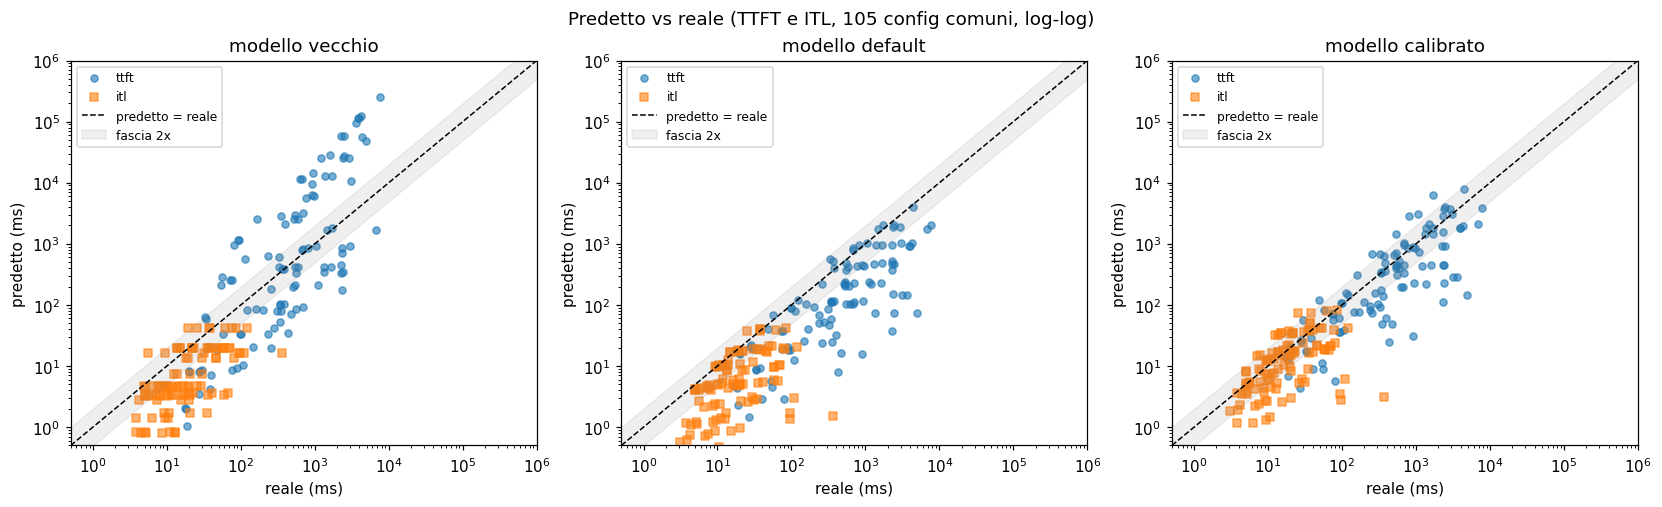

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, (name, d) in zip(axes, paired_common.items()):
    for met, marker in [("ttft_avg_ms", "o"), ("itl_avg_ms", "s")]:
        ax.scatter(d[met], d[met + "_pred"], s=22, marker=marker, alpha=0.6,
                   label=met.replace("_avg_ms", ""))
    lims = [0.5, 1e6]
    ax.plot(lims, lims, "k--", lw=1, label="predetto = reale")
    ax.fill_between(lims, [l / 2 for l in lims], [l * 2 for l in lims], color="grey", alpha=0.12, label="fascia 2x")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("reale (ms)"); ax.set_ylabel("predetto (ms)")
    ax.set_title(f"modello {name}"); ax.legend(fontsize=8)
fig.suptitle("Predetto vs reale (TTFT e ITL, 105 config comuni, log-log)")
plt.show()

Lettura dei tre pannelli: nel **vecchio** i punti TTFT su PCIe schizzano ordini
di grandezza sopra la diagonale (penalità quadratica) mentre l'ITL sta sotto —
errori di natura diversa per regime, non correggibili con una costante. Nel
**roofline default** i punti si compattano in una banda sotto la diagonale
(sottostima uniforme). Nel **calibrato** la banda è centrata sulla diagonale.

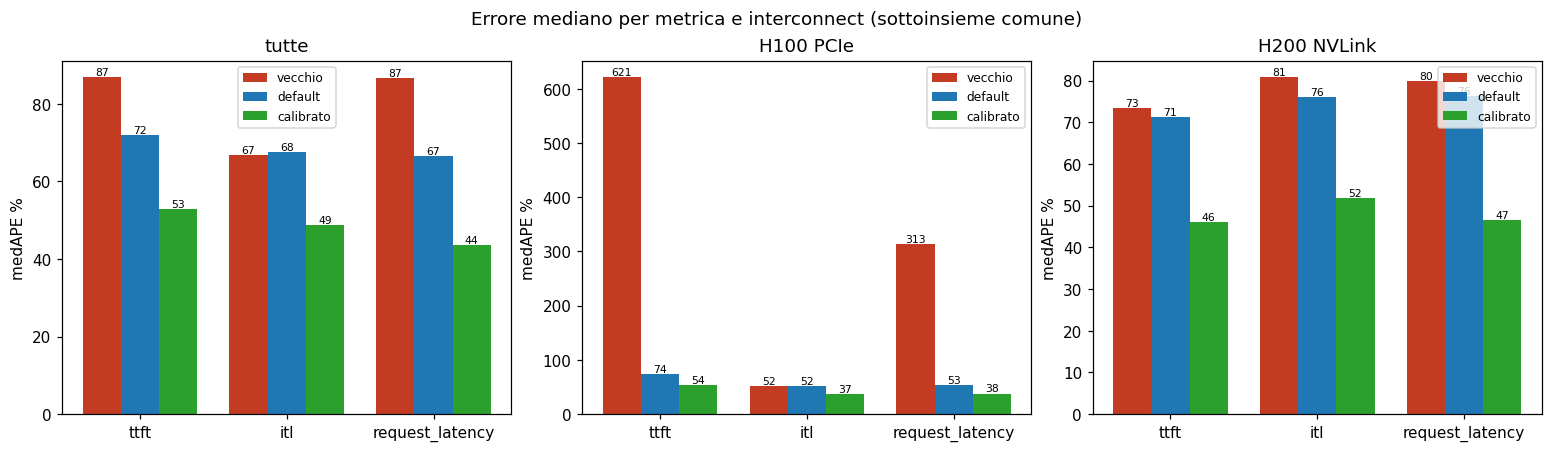

In [6]:
groups = [("tutte", None), ("H100 PCIe", "PCIe"), ("H200 NVLink", "NVLink")]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
x = np.arange(len(METRICS)); w = 0.26
for ax, (title, ic) in zip(axes, groups):
    for i, (name, d) in enumerate(paired_common.items()):
        sub = d if ic is None else d[d.interconnect == ic]
        vals = [ape(sub, met).median() for met in METRICS]
        bars = ax.bar(x + (i - 1) * w, vals, w, label=name, color=COL[name])
        ax.bar_label(bars, fmt="%.0f", fontsize=7)
    ax.set_xticks(x, [m.replace("_avg_ms", "") for m in METRICS])
    ax.set_title(title); ax.set_ylabel("medAPE %"); ax.legend(fontsize=8)
fig.suptitle("Errore mediano per metrica e interconnect (sottoinsieme comune)")
fig.savefig("results/figures/generations_medape.png", dpi=150, bbox_inches="tight")
plt.show()

### Errore vs concorrenza e distribuzione del bias

Il vecchio TTFT peggiorava per costruzione con la concorrenza (`prompt=C×input`).
Dopo la calibrazione l'errore è piatto in C sul TTFT (il fattore di coda
`(N+1)/2` è stato validato dal fit: esponente ottimo q≈0.97) e senza trend
esplosivi sull'ITL; il residuo è varianza tra modelli/configurazioni, non bias.

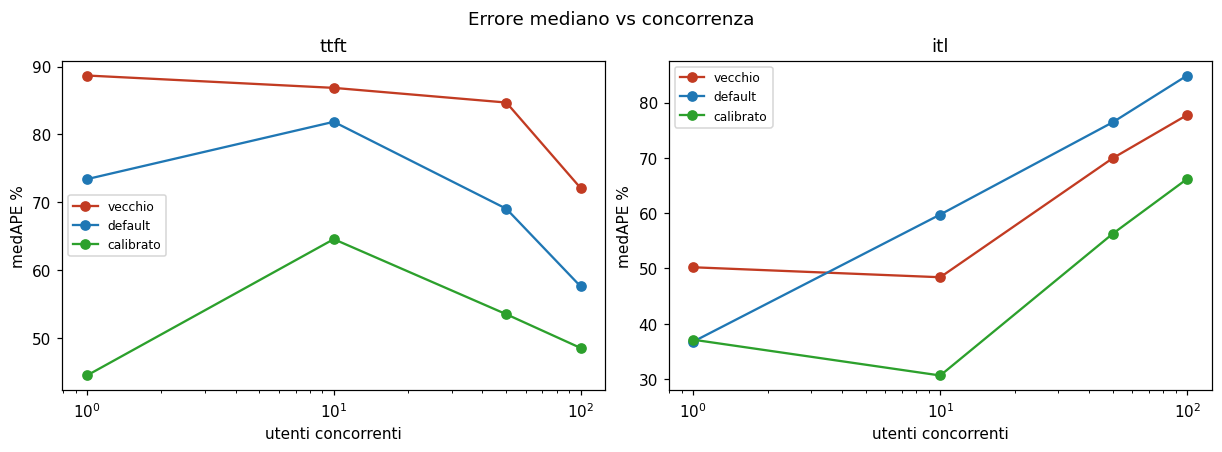

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, met in zip(axes, ["ttft_avg_ms", "itl_avg_ms"]):
    for name, d in paired_common.items():
        trend = d.groupby("concurrent_users").apply(lambda g: ape(g, met).median(), include_groups=False)
        ax.plot(trend.index, trend.values, "-o", color=COL[name], label=name)
    ax.set_xscale("log"); ax.set_xlabel("utenti concorrenti")
    ax.set_ylabel("medAPE %"); ax.set_title(met.replace("_avg_ms", "")); ax.legend(fontsize=8)
fig.suptitle("Errore mediano vs concorrenza")
plt.show()

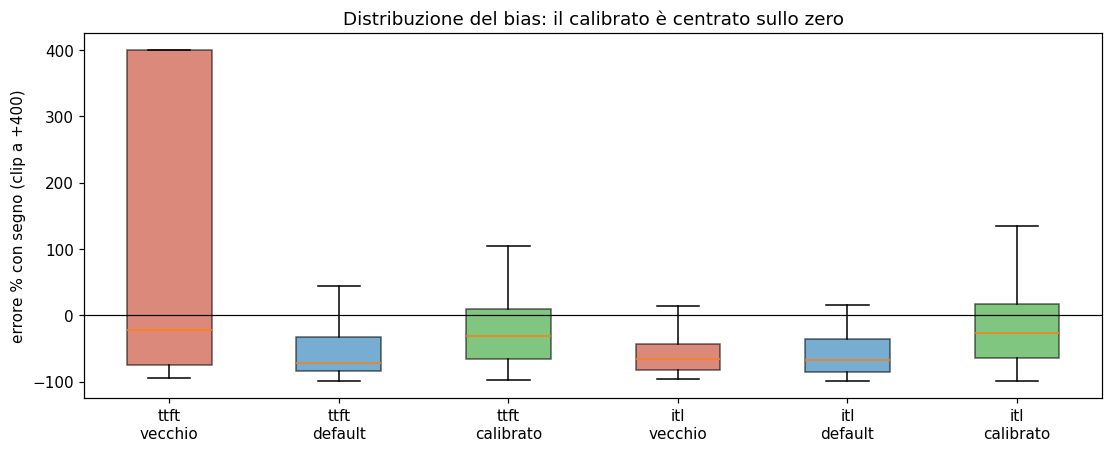

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
data, labels, colors = [], [], []
for met in ["ttft_avg_ms", "itl_avg_ms"]:
    for name, d in paired_common.items():
        data.append(np.clip(spe(d, met), -100, 400))
        labels.append(f"{met.replace('_avg_ms', '')}\n{name}")
        colors.append(COL[name])
bp = ax.boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("errore % con segno (clip a +400)")
ax.set_title("Distribuzione del bias: il calibrato è centrato sullo zero")
plt.show()

## 3. Drill-down su configurazioni rappresentative

Curve reale vs le tre versioni al variare della concorrenza, TTFT e ITL.

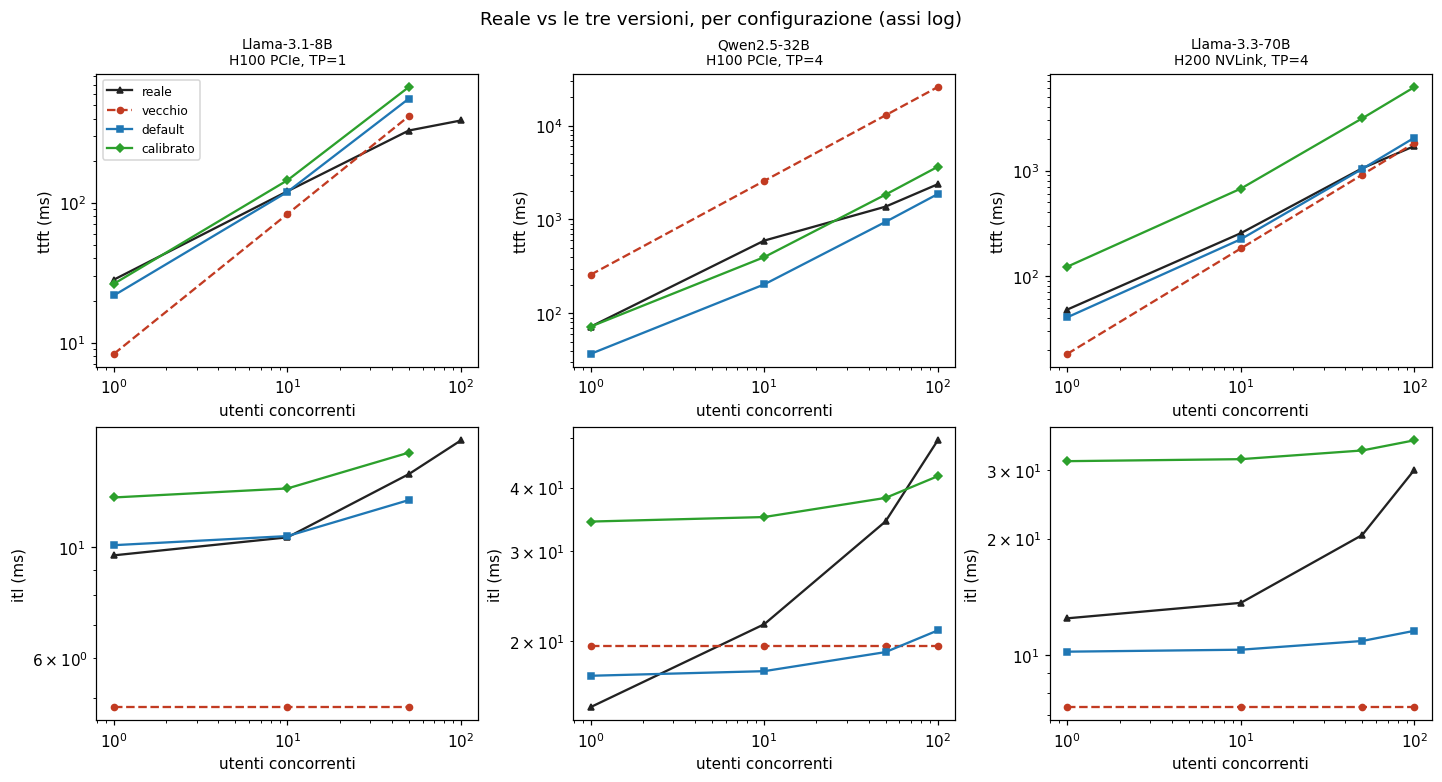

In [9]:
drill = [("Llama-3.1-8B-Instruct", "H100", "PCIe", 1),
         ("Qwen2.5-32B-Instruct", "H100", "PCIe", 4),
         ("Llama-3.3-70B-Instruct", "H200", "NVLink", 4)]
fig, axes = plt.subplots(2, len(drill), figsize=(13, 7), constrained_layout=True)
for j, (mod, arch, ic, tp) in enumerate(drill):
    for i, met in enumerate(["ttft_avg_ms", "itl_avg_ms"]):
        ax = axes[i][j]
        series = [("reale", real, "-^")] + [(k, v, "--o" if k == "vecchio" else "-s" if k == "default" else "-D")
                                            for k, v in preds.items()]
        for name, df, style in series:
            sub = df[(df.model == mod) & (df.gpu_arch == arch) &
                     (df.interconnect == ic) & (df.n_gpu == tp)].sort_values("concurrent_users")
            if len(sub):
                ax.plot(sub.concurrent_users, sub[met], style, color=COL[name], label=name, ms=4)
        ax.set_xscale("log"); ax.set_yscale("log")
        if i == 0:
            ax.set_title(f"{mod.split('-Instruct')[0]}\n{arch} {ic}, TP={tp}", fontsize=9)
        ax.set_ylabel(met.replace("_avg_ms", "") + " (ms)")
        ax.set_xlabel("utenti concorrenti")
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
fig.suptitle("Reale vs le tre versioni, per configurazione (assi log)")
plt.show()

## 4. Conclusioni

Sul sottoinsieme comune di **105 configurazioni** appaiate al benchmark reale
(i numeri esatti sono nella tabella `summary` sopra):

| | 1. vecchio | 2. roofline default | 3. roofline calibrato |
|---|---|---|---|
| TTFT medAPE | 86.9% | 71.9% | **52.9%** |
| TTFT MAPE (sensibile alle code) | 478.6% | 61.5% | 57.4% |
| TTFT medAPE su H100 PCIe | **621%** | 74.0% | **54.1%** |
| ITL medAPE | 66.7% | 67.6% | **48.7%** |
| request_latency medAPE | 86.7% | 66.6% | **43.6%** |
| bias mediano TTFT / ITL | −22% / −66% (regimi misti) | −72% / −68% (uniforme) | **−32% / −26%** |
| config reali coperte | 105 | 147 | 147 |

I risultati che contano:

1. **Cambio di modello (1→2): sparisce il regime catastrofico.** Il vecchio
   modello era discreto su NVLink e fuori di un ordine di grandezza su PCIe
   multi-GPU (penalità quadratica): errori di natura diversa per regime, non
   correggibili con una costante. Il roofline ha lo stesso comportamento sui due
   interconnect e MAPE TTFT ~8× più bassa, con bias uniforme.
2. **Calibrazione (2→3): il bias uniforme si corregge davvero.** Fit a 4
   parametri (`mfu=0.413`, `mbu=0.643`, `η_nv=0.361`, `η_pcie=0.372`) con
   `backend/calibrate_perf_model.py` sui **soli modelli densi**: errori mediani
   giù di ~19 punti su tutte le metriche e bias più che dimezzato (sui densi è
   ~0; il residuo −32%/−26% sul subset comune viene da gpt-oss, vedi punto 4).
   **Finding collaterale**: l'efficienza di scaling TP fittata è ~0.36-0.37 su
   *entrambi* gli interconnect — a queste dimensioni di trasferimento (512/128
   token) il TP di vLLM è limitato dalla latenza degli allreduce, non dalla
   banda NVLink/PCIe.
3. **Il fattore di coda `(N+1)/2` del TTFT è validato** (esponente ottimo
   q≈0.97 ≈ 1). Il termine KV/contention dell'ITL vorrebbe invece un
   moltiplicatore ~4× (contention reale più forte), ma il guadagno
   sull'obiettivo è piccolo (~3%): registrato come lavoro futuro.
4. **Il MoE è fuori dal dominio della formula chiusa.** Con le spec della
   model card (5.1B attivi) il roofline sottostima gpt-oss-120b di ~5×: il
   costo effettivo di serving di un MoE sparso (kernel grouped-GEMM, traffico
   pesi per-batch) è molto sopra i parametri attivi nominali — il vecchio
   valore euristico (27.09B) era di fatto un buon "costo effettivo". Per questo
   gpt-oss è escluso dal fit e dichiarato fuori dominio.
5. **Posizionamento vs ML** (notebook di tesi, LOMO): il modello fisico
   calibrato arriva a medAPE ~49–53% (TTFT/ITL), la pipeline ML a ~29–40%. Il
   fisico resta interpretabile e estrapolabile a GPU/modelli mai visti; l'ML
   cattura anche gli effetti per-modello e di batching/scheduling che il
   roofline media. Sono complementari — esattamente la tesi del lavoro.